In [2]:
!pip install casadi &> /dev/null # for numerical optimization
!pip install do_mpc  &> /dev/null # toolbox to deploy model predictive control systems
!pip install botorch  &> /dev/null
!pip install scikit-quant  &> /dev/null # for quantum machine learning and optimization

In [3]:
import numpy as np
import sys
from casadi import *
import pdb
import do_mpc
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
from matplotlib.animation import FuncAnimation, FFMpegWriter, ImageMagickWriter
import math
import gpytorch
import botorch
import torch
torch.set_default_dtype(torch.float64)
from botorch.utils.sampling import draw_sobol_samples
from torch.quasirandom import SobolEngine
from gpytorch.kernels import MaternKernel, ScaleKernel, RBFKernel, LinearKernel, PeriodicKernel
from botorch.acquisition import ExpectedImprovement, UpperConfidenceBound, PosteriorMean
from botorch.optim import optimize_acqf
from botorch.sampling import SobolQMCNormalSampler
from gpytorch.constraints.constraints import Interval
from gpytorch.likelihoods.gaussian_likelihood import GaussianLikelihood
from gpytorch.constraints import GreaterThan
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.models.transforms.input import Normalize
from botorch.optim import optimize_acqf
import time
from scipy import optimize
from skquant.opt import minimize as skqmin

# turn off warnings for clean output
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/usr/local/lib/python3.12/dist-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


# CLOSED LOOP SIMULATOR USING MPC STRATEGY
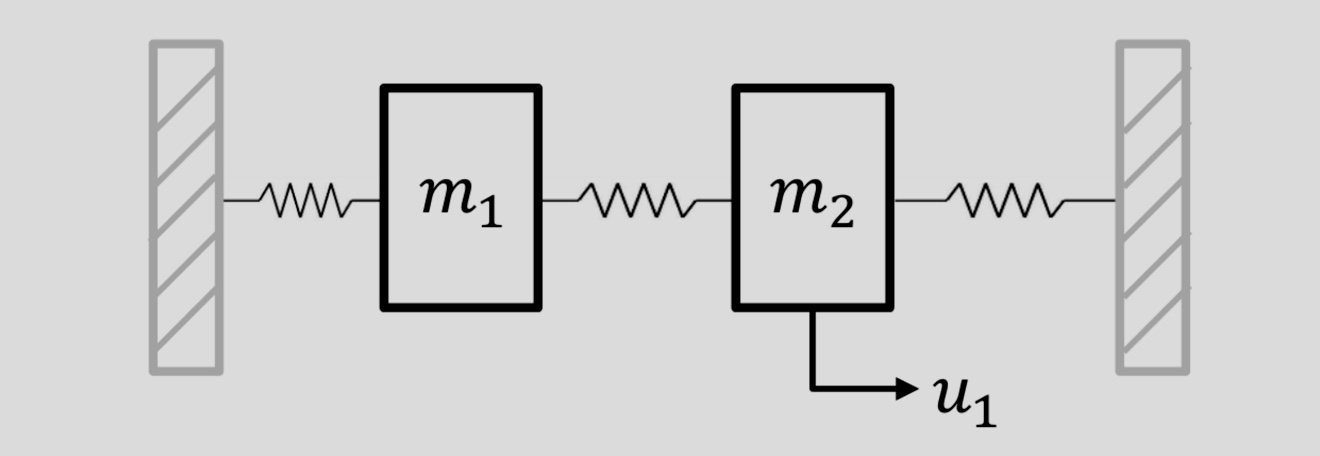


TO know more about the model we're dealing with refer: https://www.do-mpc.com/en/latest/example_gallery/oscillating_masses_discrete.html

We have two objects connected visa springs and attached to walls on both sides. The system is expected to be in a continous state but we use a discrete formula to track the state of the system every 0.5 seconds and its simplifie using a formula:


```
X(t+1) = A(x)+B(u)
u -> being the inital foce applied to the mass on the right that induces movement in the system
A -> captues how the state evolves in 0l5 seconds without any external force
B -> captures how the external force influences the system after 0.5 seconds, the force changes linearly
```






In [4]:
B_true = [0.014,   0.063,   0.221,  0.367]

In [5]:
from numpy.matrixlib import bmat

e = np.ones([4,1])
np.random.seed(0)
x00 = np.random.uniform(-3*e, 3*e) # sets the lower and upper bound for the [4,1] matrix

In [6]:
'''
You define the system's dynamics — how the state changes in discrete time —
by specifying the right-hand side (rhs) for each state
'''
model_type = "discrete"
true_model = do_mpc.model.Model(model_type=model_type)
# x=[s1,v1,s2,v2] - (the state vector of positions and velocities) -
# current state of the system at each discrete time step and are updated based on the model dynamics.
_x = true_model.set_variable(var_type="_x",var_name="x",shape=(4,1))
# u=[u1] (the input force applied to the right mass)
_y = true_model.set_variable(var_type="_u",var_name="u",shape=(1,1))

In [7]:
'''
A- state map of the system that helps in computing the next state given the given
state and velocities of the masses
B- matrix of the inital force that influences the system in the future
'''
A = np.array([[ 0.763,  0.460,  0.115,  0.020],
              [-0.899,  0.763,  0.420,  0.115],
              [ 0.115,  0.020,  0.763,  0.460],
              [ 0.420,  0.115, -0.899,  0.763]])

B = np.array([[B_true[0]],   [B_true[1]],   [B_true[2]],  [B_true[3]]])

In [8]:
x_next = A@_x + B@_y

true_model.set_rhs("x",x_next)
# set cost factor to penalize for shifting from zero
true_model.set_expression("cost",sum1(_x**2))
true_model.setup()

In [9]:
def closedloop_sys(B, specified_theta0=None, get_mpc=False):
  model_type = "discrete"
  model = do_mpc.model.Model(model_type=model_type)

  _x = model.set_variable(var_type='_x', var_name='x', shape=(4,1))
  _u = model.set_variable(var_type='_u', var_name='u', shape=(1,1))

  Am = np.array([[ 0.763,  0.460,  0.115,  0.020],
                [-0.899,  0.763,  0.420,  0.115],
                [ 0.115,  0.020,  0.763,  0.460],
                [ 0.420,  0.115, -0.899,  0.763]])

  Bm = np.array([ [B[0]],   [B[1]],   [B[2]],  [B[3]] ]) # use our guess values

  x_next = Am@_x + Bm@_u
  model.set_rhs("x",x_next)
  model.set_expression("cost",sum1(_x**2))
  model.setup()

  # setting control using mismatched "model"
  '''
  controller - It computes an optimal sequence of control inputs to minimize
  a specified cost function (like minimizing deviations and control effort)
  over a prediction horizon.
  1. Supports nonlinear and linear models.
  2. Allows constraints on inputs and states.
  3. Handles cost functions with different terms (stage cost, terminal cost).
  4. Compatible with continuous and discrete time models.
  5. Integrates uncertainties and robustness features.
  '''
  mpc_controller = do_mpc.controller.MPC(model)
  setup_mpc = {
      'n_robust': 0,
      'n_horizon': 7,
      't_step': 0.5,
      'state_discretization': 'discrete',
      'store_full_solution':True,
      # Use MA27 linear solver in ipopt for faster calculations:
      'nlpsol_opts': {'ipopt.linear_solver': 'mumps',
                    'ipopt.print_level':0,
                    'print_time':0,
                    'ipopt.sb': 'yes',
                    },
              }
  mpc_controller.set_param(**setup_mpc)

  m_term = model.aux['cost'] # terminal cost
  l_term = model.aux['cost'] # stage cost
  mpc_controller.set_objective(mterm=m_term,lterm=l_term)
  mpc_controller.set_rterm(u=1e-4) # input penalty

  # define state bounds
  max_x = np.array([[4.0], [10.0], [4.0], [10.0]])
  # lower bounds of the states
  mpc_controller.bounds['lower','_x','x'] = -max_x
  # upper bounds of the states
  mpc_controller.bounds['upper','_x','x'] = max_x
  # lower bounds of the input
  mpc_controller.bounds['lower','_u','u'] = -0.5
  # upper bounds of the input
  mpc_controller.bounds['upper','_u','u'] =  0.5

  mpc_controller.setup()
  # define an estimator
  # (in this case, full state feedback, so the estimator is just an identity)
  estimator = do_mpc.estimator.StateFeedback(true_model)
  # set inital state
  x_0 = x00
  if specified_theta0 is not None:
    x_0 = specified_theta0.numpy()
  mpc_controller.x0 = x_0
  mpc_controller.set_initial_guess() # easy for optimization

  x0 = x_0
  thetas = [x0[:]]

  # set up simulator
  simulatorCL = do_mpc.simulator.Simulator(model)
  simulatorCL.set_param(t_step = 0.5)
  simulatorCL.setup()

  # specify I.C. for closed loop simulator
  if specified_theta0 is None:
    simulatorCL.x0 = x0
  else:
    simulatorCL.x0 = casadi.DM(specified_theta0.numpy())
  simulatorCL.setup()

  # Run Closed-loop simulator
  n_steps = 40
  for k in range(n_steps):
      try:
        u0 = mpc_controller.make_step(x0)
        y_next = simulatorCL.make_step(u0)
      except:
        print('!!!!!!      ', k,'      !!!!!!' )
        print("Failed to find a fesible control action and simulator crashed... ")
        print("...retrying with purturbed control action ")
        y_next = simulatorCL.make_step(u0*.99)

      x0 = estimator.make_step(y_next)
      thetas.append(x0[:])

  sol = np.sum( (mpc_controller.data['_x'])**2 )

  if get_mpc == False:
    return sol, thetas
  else:
    return sol, thetas, mpc_controller



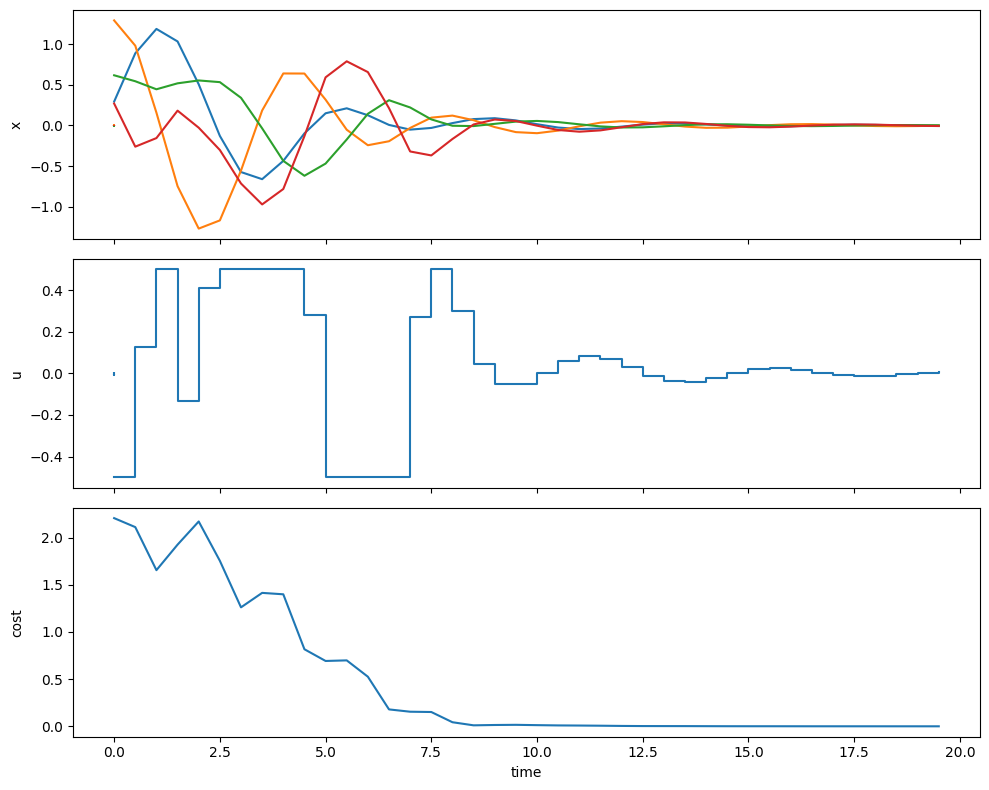

Closed-loop score with true B values: 19.246087215707057


In [10]:
true_cost, thetas_good, mpc_true = closedloop_sys(B.flatten(),get_mpc=True)
fig,ax,graphics = do_mpc.graphics.default_plot(mpc_true.data, figsize=(10,8))
graphics.plot_results()
graphics.reset_axes()
plt.show()
print('Closed-loop score with true B values:', true_cost);

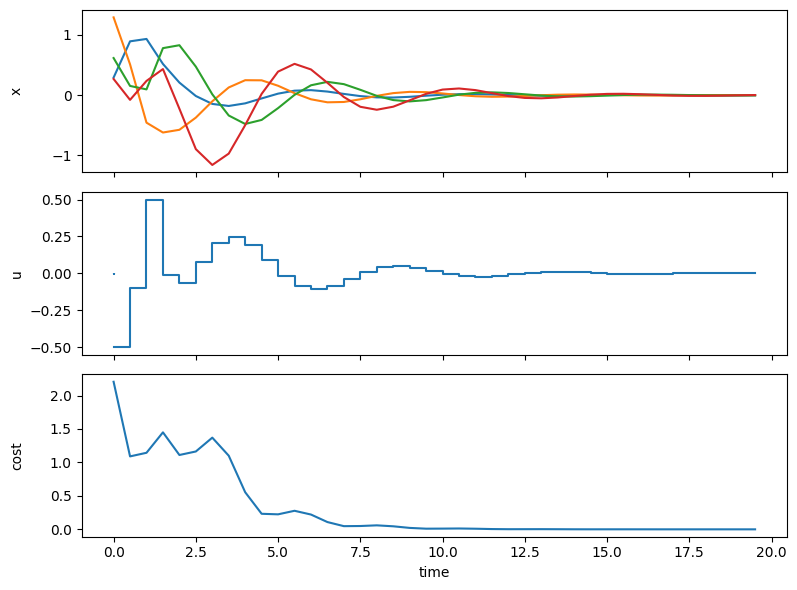

Closed-loop score with guessed B values: 12.53813170711043


In [11]:
# Try some guesses for B and see how well you can do in terms of performance
B_guess = [0.0, 1.0, 1.0, 0.0]
cost_guess, _, mpc_guess = closedloop_sys(B_guess, get_mpc=True)
fig, ax, graphics = do_mpc.graphics.default_plot(mpc_guess.data, figsize=(8,6))
graphics.plot_results()
graphics.reset_axes()
plt.show()
print('Closed-loop score with guessed B values:', cost_guess);

1.   Train a GP model given the most recent data.
2.   Define a suitable acquisition function (that represents roughly value of information).
3.   Maximize acquisition function to identify next best sample point.
4.   Query function at sample and add to data history.

In [12]:
def surrogate_func(X,Y,kernel_type,noise_free=False, plot_1d=False, plot_bounds=None):
  if X.ndim < 2:
    print("Needs to have 2 dimensions")
  if Y.ndim == 1:
    Y = Y.unsqueeze(-1)

  # input scaling
  normalize = Normalize(d=X.shape[-1])
  input_transform = normalize

  # output scaling
  standardize = Standardize(m=Y.shape[-1])
  outcome_transform = standardize

  # select covariance module
  input_dim = X.shape[-1]
  if kernel_type == 'RBF':
      covar_module = ScaleKernel(RBFKernel(ard_num_dims=input_dim))
  elif kernel_type == 'Linear':
      covar_module = ScaleKernel(LinearKernel(ard_num_dims=input_dim))
  elif kernel_type == 'Periodic':
      covar_module = ScaleKernel(PeriodicKernel(ard_num_dims=input_dim))
  elif kernel_type == 'Matern05':
      covar_module = ScaleKernel(MaternKernel(nu=0.5, ard_num_dims=input_dim))
  elif kernel_type == 'Matern15':
      covar_module = ScaleKernel(MaternKernel(nu=1.5, ard_num_dims=input_dim))
  elif kernel_type == 'Matern25':
      covar_module = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=input_dim))

  # set the likelihood
  if noise_free:
    likelihood = GaussianLikelihood(noise_constraint=Interval(lower_bound=1e-5, upper_bound=1e-3))
  else:
    likelihood = GaussianLikelihood(noise_constraint=Interval(lower_bound=1e-5, upper_bound=100))

  # define the model
  model = SingleTaskGP(train_X=X, train_Y=Y, covar_module=covar_module, likelihood=likelihood, outcome_transform=outcome_transform, input_transform=input_transform)
  model.outcome_transform.eval()
  mll = gpytorch.mlls.ExactMarginalLogLikelihood(model.likelihood, model)
  fit_gpytorch_mll(mll)

  model.eval()

  if plot_1d:
    if input_dim == 1:
      if plot_bounds is None:
        print("Plot bounds not specified!")
      else:
        x_list = torch.linspace(plot_bounds[0], plot_bounds[1], 101)
        preds = model.posterior(x_list.unsqueeze(-1))
        mean = preds.mean.squeeze()
        var = preds.variance.squeeze()
        lcb = mean - 2*torch.sqrt(var)
        ucb = mean + 2*torch.sqrt(var)
        plt.figure(figsize=(8,6))
        plt.plot(x_list, mean.detach().numpy())
        plt.fill_between(x_list, lcb.detach().numpy(), ucb.detach().numpy(), alpha=0.2)
        plt.scatter(X.detach().numpy(), Y.detach().numpy(), color ='red', marker ='*')
        plt.xlabel('input')
        plt.ylabel('target')
    else:
      print("Too many input dimensions to plot!")

  # return the trained model
  return model

In [13]:
def optimize_acq(acq,xL,xU):
  num_restarts = 20
  raw_samples=2000
  nx = xL.shape[0]
  bounds = torch.tensor([[xL[j],xU[j]] for j in range(nx)]).T

  new_point, acq_value_list = optimize_acqf(acq_function=acq, bounds=bounds, q=1, num_restarts=num_restarts, raw_samples=raw_samples, options={})
  try:
    acq_val = acq_value_list.numpy()

  except:
    print('Optimizing the acqusition failed, so taking single random point')
    new_point = bounds[0] + (bounds[1] - bounds[0]) * torch.rand(1, nx)
    acq_val = float('nan')

  return new_point, acq_val

The recommended point is 0.0
The acquisition function is 0.08187444769153274


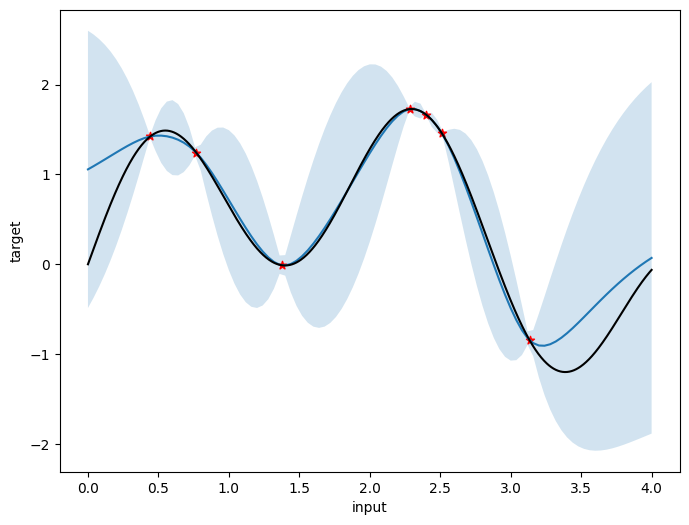

In [14]:
# write a simple 1d function [feel free to modify]
f = lambda x: torch.sin(x) + torch.sin((10.0 / 3.0) * x)

# define input range
x_min, x_max = 0.0, 4.0

# generate some number of random data points
Ninit = 7
torch.manual_seed(8)
x_train = (x_max-x_min)*torch.rand((Ninit,1)) + x_min
y_train = f(x_train)

# fit model
model = surrogate_func(x_train, y_train, 'Matern15', noise_free=True, plot_1d=True, plot_bounds=(x_min, x_max))
xlist = torch.linspace(x_min, x_max, 1001)
plt.plot(xlist, f(xlist), '-k');

# optimize ei
best_value = y_train.max()
ei = ExpectedImprovement(model=model, best_f=best_value, maximize=True)
new_x, acq_val = optimize_acq(ei, torch.tensor([x_min]), torch.tensor([x_max]))
print(f"The recommended point is {new_x.detach().numpy().squeeze()}")
print(f"The acquisition function is {acq_val}")

In [15]:
# User parameters
nreps = 1         # number of full optimiztion rounds
total_evals = 50  # num total budget (includes n_init)
n_init = 5        # num init samples
n_sa = 1          # num sample avg

# Data for BO method
BO_losses = torch.zeros(nreps, total_evals-n_init)
BO_Bvec  = torch.zeros(nreps, total_evals-n_init, 4)
BO_y     = torch.zeros(nreps, total_evals-n_init)

# Data for random search method
RD_losses = torch.zeros(nreps, total_evals)
RD_Bvec  = torch.zeros(nreps, total_evals, 4)
RD_y     = torch.zeros(nreps, total_evals)

# Data for Snobfit method
SF_losses = torch.zeros(nreps, total_evals)
SF_Bvec  = torch.zeros(nreps, total_evals, 4)
SF_y     = torch.zeros(nreps, total_evals)

# Fix seed
np.random.seed(0)
rand_ic = torch.tensor(np.random.uniform(-3*e,3*e, (4,n_sa)))

# Evaluate true score
ts = 0
for i in range(n_sa):
  ts+= closedloop_sys(B_true, rand_ic[:,i])[0]
True_Score = ts/n_sa
print(True_Score)

19.246087215707057


In [16]:
# loop over replicates
for j in range(nreps):
  # bounds
  bounds = torch.tensor([[0]*4, [1]*4]).double()
  dim = bounds.shape[1]

  # generate some random initial data
  torch.random.manual_seed(0)
  sobol = SobolEngine(dimension=dim, scramble=True, )
  train_x = torch.empty(total_evals, dim)
  train_x[:n_init,:] = sobol.draw(n=n_init)
  train_x[:n_init,:] = train_x[:n_init,:]*(bounds[1]-bounds[0])+bounds[0]

  # evaluate function at random samples
  train_y = torch.empty(total_evals, 1)
  for i in range(n_init):
    yi = 0
    for ii in range(n_sa):
     yi += closedloop_sys(train_x[i,:].numpy(),  rand_ic[:,ii])[0]
     train_y[i,:] = yi/n_sa

  BO_losses[j, 0] = train_y[:n_init,:].min().item()
  for k in range(total_evals-n_init-1):
      #fit model
      model = surrogate_func(train_x[:k+n_init,:], train_y[:k+n_init,:], 'RBF', noise_free=True)

      #build and opt EI Acq fun
      best_value = y_train.min()
      ei = ExpectedImprovement(model=model, best_f=best_value, maximize=False)
      candidates, acq_val = optimize_acqf(ei, bounds=bounds, q=1, num_restarts=10, raw_samples=1000)

      # observe new values
      new_x = candidates.detach()
      train_x[k+n_init,:] = new_x
      yi = 0
      for i in range(n_sa):
        yi += closedloop_sys(new_x.numpy().flatten(), rand_ic[:,i])[0]
      train_y[k+n_init,:] = yi/n_sa

      # save results
      BO_losses[j,k+1]    = train_y[:k+n_init,:].min().item()
      BO_Bvec[j,k+1, :]   = new_x
      BO_y[j,k+1]         = train_y[k+n_init,:].item()

      # print current results
      print("Round %03d --- it: %03d, loss: %3.3f, best: %3.3f" %
            (j+1,
             k+1,
             train_y[k+n_init,:].item(),
             train_y[:k+n_init,:].min().item() ))

Round 001 --- it: 001, loss: 14.958, best: 4.893
Round 001 --- it: 002, loss: 11.895, best: 4.893
Round 001 --- it: 003, loss: 10.314, best: 4.893
Round 001 --- it: 004, loss: 15.916, best: 4.893
Round 001 --- it: 005, loss: 5.086, best: 4.893
Round 001 --- it: 006, loss: 6.809, best: 4.893
Round 001 --- it: 007, loss: 10.360, best: 4.893
Round 001 --- it: 008, loss: 20.496, best: 4.893
Round 001 --- it: 009, loss: 15.292, best: 4.893
Round 001 --- it: 010, loss: 22.128, best: 4.893
Round 001 --- it: 011, loss: 7.926, best: 4.893
Round 001 --- it: 012, loss: 16.398, best: 4.893
Round 001 --- it: 013, loss: 5.635, best: 4.893
Round 001 --- it: 014, loss: 12.295, best: 4.893
Round 001 --- it: 015, loss: 10.063, best: 4.893
Round 001 --- it: 016, loss: 15.381, best: 4.893
Round 001 --- it: 017, loss: 11.257, best: 4.893
Round 001 --- it: 018, loss: 7.233, best: 4.893
Round 001 --- it: 019, loss: 6.661, best: 4.893
Round 001 --- it: 020, loss: 3.145, best: 4.893
Round 001 --- it: 021, loss

In [17]:
for j in range(nreps):

  train_x = sobol.draw(n=total_evals)
  train_x = train_x*(bounds[1]-bounds[0])+bounds[0]

  train_y = torch.empty(total_evals, 1)
  for i in range(total_evals):
    train_y[i,:] = closedloop_sys(train_x[i,:].numpy(), rand_ic[:,0])[0]

    RD_losses[j,i]    = train_y[:i+1,:].min().item()
    RD_Bvec[j,i, :]   = train_x[i,:]
    RD_y[j,i]         = train_y[i,:].item()
    print("Round %03d --- it: %03d, loss: %3.3f, best: %3.3f" % (j+1, i+1, train_y[i,:].item(),  train_y[:i+1,:].min().item() ))


Round 001 --- it: 001, loss: 4.795, best: 4.795
Round 001 --- it: 002, loss: 20.754, best: 4.795
Round 001 --- it: 003, loss: 11.226, best: 4.795
Round 001 --- it: 004, loss: 9.812, best: 4.795
Round 001 --- it: 005, loss: 10.413, best: 4.795
Round 001 --- it: 006, loss: 10.416, best: 4.795
Round 001 --- it: 007, loss: 19.093, best: 4.795
Round 001 --- it: 008, loss: 20.643, best: 4.795
Round 001 --- it: 009, loss: 15.126, best: 4.795
Round 001 --- it: 010, loss: 6.678, best: 4.795
Round 001 --- it: 011, loss: 15.254, best: 4.795
Round 001 --- it: 012, loss: 14.312, best: 4.795
Round 001 --- it: 013, loss: 15.728, best: 4.795
Round 001 --- it: 014, loss: 10.931, best: 4.795
Round 001 --- it: 015, loss: 15.731, best: 4.795
Round 001 --- it: 016, loss: 14.448, best: 4.795
Round 001 --- it: 017, loss: 8.563, best: 4.795
Round 001 --- it: 018, loss: 4.150, best: 4.150
Round 001 --- it: 019, loss: 16.127, best: 4.150
Round 001 --- it: 020, loss: 14.137, best: 4.150
Round 001 --- it: 021, lo

In [18]:
for j in range(nreps):

  train_x = sobol.draw(n=total_evals)
  train_x = train_x*(bounds[1]-bounds[0])+bounds[0]

  train_y = torch.empty(total_evals, 1)
  for i in range(total_evals):
    train_y[i,:] = closedloop_sys(train_x[i,:].numpy(), rand_ic[:,0])[0]

    RD_losses[j,i]    = train_y[:i+1,:].min().item()
    RD_Bvec[j,i, :]   = train_x[i,:]
    RD_y[j,i]         = train_y[i,:].item()
    print("Round %03d --- it: %03d, loss: %3.3f, best: %3.3f" % (j+1, i+1, train_y[i,:].item(),  train_y[:i+1,:].min().item() ))


Round 001 --- it: 001, loss: 14.140, best: 14.140
Round 001 --- it: 002, loss: 6.669, best: 6.669
Round 001 --- it: 003, loss: 8.413, best: 6.669
Round 001 --- it: 004, loss: 7.008, best: 6.669
Round 001 --- it: 005, loss: 15.768, best: 6.669
Round 001 --- it: 006, loss: 15.583, best: 6.669
Round 001 --- it: 007, loss: 10.232, best: 6.669
Round 001 --- it: 008, loss: 14.516, best: 6.669
Round 001 --- it: 009, loss: 6.914, best: 6.669
Round 001 --- it: 010, loss: 13.244, best: 6.669
Round 001 --- it: 011, loss: 5.634, best: 5.634
Round 001 --- it: 012, loss: 24.028, best: 5.634
Round 001 --- it: 013, loss: 15.826, best: 5.634
Round 001 --- it: 014, loss: 14.039, best: 5.634
Round 001 --- it: 015, loss: 19.479, best: 5.634
Round 001 --- it: 016, loss: 4.674, best: 4.674
Round 001 --- it: 017, loss: 15.605, best: 4.674
Round 001 --- it: 018, loss: 24.033, best: 4.674
Round 001 --- it: 019, loss: 7.661, best: 4.674
Round 001 --- it: 020, loss: 8.134, best: 4.674
Round 001 --- it: 021, loss

In [18]:
def cl_sim(x):
  return closedloop_sim(x, rand_ic[:,0])[0]

for j in range(nreps):
    print(j)
    x0 = sobol.draw(n=1)
    x0 = x0*(bounds[1]-bounds[0])+bounds[0]

    res, his = skqmin(cl_sim, x0.numpy().flatten(), bounds.T.numpy(), total_evals+10,method='snobfit')#  callback=callbackF)

    SF_y[j,:]         = torch.tensor(his[:total_evals,0])
    SF_losses[j,:]    = torch.tensor([SF_y[j,:i+1].min().item() for i in range(total_evals)])
    SF_Bvec[j,:,:]    = torch.tensor(his[:total_evals,1:])


In [19]:
arg = BO_y[:,1:].argmin() +1
best_x_bo  = BO_Bvec[0,arg,:]
best_x_rd = RD_Bvec[0,RD_y.argmin(),:]
best_x_sf = SF_Bvec[0,SF_y.argmin(),:]


print( 'Best cost (BO): ', BO_y[:,1:].min().item() )
print( 'Best cost (RD): ', RD_y[:,1:].min().item() )
print( 'Best cost (SF): ', SF_y[:,1:].min().item() )
print('True cost : ', True_Score)
print()
print( 'Best B values (BO): ', best_x_bo)
print( 'Best B values (RD): ', best_x_rd)
print( 'Best B values (SF): ', best_x_sf)
print('True B values : ', B_true)

Best cost (BO):  3.144954069322319
Best cost (RD):  4.1427113568076654
Best cost (SF):  0.0
True cost :  19.246087215707057

Best B values (BO):  tensor([1.0000, 1.0000, 0.5117, 0.0000])
Best B values (RD):  tensor([0.7204, 0.5977, 0.4318, 0.0192])
Best B values (SF):  tensor([0., 0., 0., 0.])
True B values :  [0.014, 0.063, 0.221, 0.367]


In [20]:
print('Dist. from true (BO): ', torch.norm( best_x_bo-torch.tensor(B_true) ).item() )
print('Dist. from True (RD): ', torch.norm( best_x_rd-torch.tensor(B_true) ).item() )
print('dist. from true (SF): ', torch.norm( best_x_sf-torch.tensor(B_true) ).item() )

Dist. from true (BO):  1.438528875709774
Dist. from True (RD):  0.9748581295921049
dist. from true (SF):  0.4332378099843087


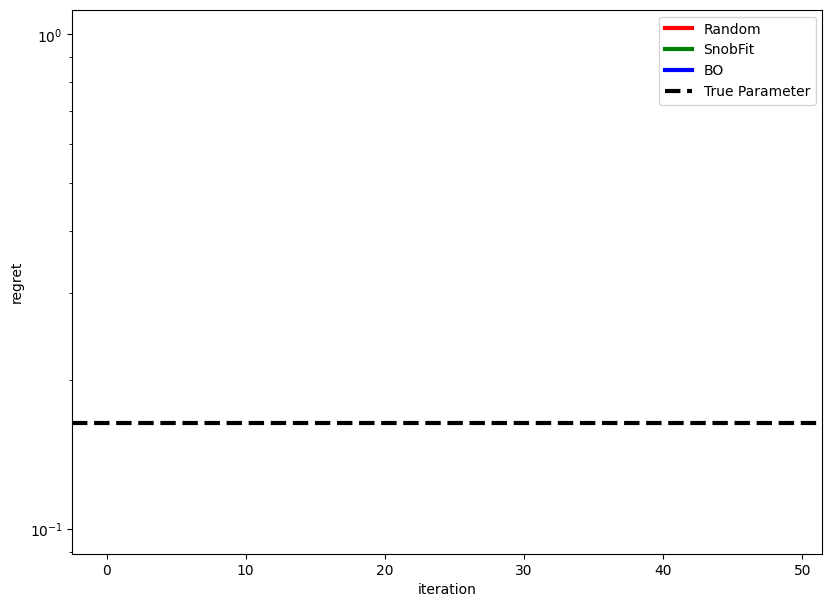

In [21]:
best = np.array(19.0826) # best solution found over 100 rounds of optimization
fig= plt.figure(figsize=(10,8))
plt.plot( RD_losses.numpy().flatten()-best, c='r', label='Random', lw=3)
plt.plot( SF_losses.numpy().flatten()-best, c='g', label='SnobFit', lw=3)
plt.plot(np.arange(n_init, total_evals), BO_losses.numpy().flatten()-best, c='b', label='BO', lw=3)
plt.axhline(True_Score-best, linestyle='--', c='k', label='True Parameter', lw=3)
plt.xlabel('iteration')
plt.ylabel('regret')
plt.subplots_adjust(left=.15, bottom=.2)
plt.legend()
plt.yscale("log")

plt.show()

In [23]:
theta_1_sims = []
thetas_good = []
thetas_bad = []
thetas_sf = []

J_learned = 0
J_true = 0
J_bad = 0
J_sf = 0

for i in range(1):
  J,theta = closedloop_sys(best_x_bo.numpy(),  rand_ic[:,i])
  theta = torch.tensor(theta)
  theta_1_sims.append(theta[:,:])
  J_learned += J

  J,theta = closedloop_sys(B_true, rand_ic[:,i])
  theta = torch.tensor(theta)
  thetas_good.append(theta[:,:])
  J_true += J

  J,theta = closedloop_sys(best_x_rd,  rand_ic[:,i])
  theta = torch.tensor(theta)
  thetas_bad.append(theta[:,:])
  J_bad += J

  J,theta = closedloop_sys(best_x_sf,  rand_ic[:,i])
  theta = torch.tensor(theta)
  thetas_sf.append(theta[:,:])
  J_sf += J


print("Average perfomance of True control parameters = ", J_true)
print("Average perfomance of learned control parameters = ", J_learned)
print("Average perfomance of SF control parameters = ", J_sf)
print("Average perfomance of RND control parameters = ", J_bad)

Average perfomance of True control parameters =  19.246087215707057
Average perfomance of learned control parameters =  3.144954069322319
Average perfomance of SF control parameters =  84.5098011828808
Average perfomance of RND control parameters =  4.1427113568076654


In [26]:
# closed loop verification

theta_0_samples =  torch.tensor([2,-1,0,-2])

#run sims
theta_1_sims = []
thetas_good = []
thetas_bad = []
thetas_sf = []

J_learned = 0
J_true = 0
J_bad = 0
J_sf = 0

for i in range(1):
  J,theta = closedloop_sys(best_x_bo.numpy(),  specified_theta0=theta_0_samples)
  theta = torch.tensor(theta)
  theta_1_sims.append(theta[:,:])
  J_learned += J

  J,theta = closedloop_sys(B_true, specified_theta0=theta_0_samples)
  theta = torch.tensor(theta)
  thetas_good.append(theta[:,:])
  J_true += J

  J,theta = closedloop_sys(best_x_rd,  specified_theta0=theta_0_samples)
  theta = torch.tensor(theta)
  thetas_bad.append(theta[:,:])
  J_bad += J

  J,theta = closedloop_sys(best_x_sf,  specified_theta0=theta_0_samples)
  theta = torch.tensor(theta)
  thetas_sf.append(theta[:,:])
  J_sf += J


print("Average perfomance of True control parameters = ", J_true)
print("Average perfomance of learned control parameters = ", J_learned)
print("Average perfomance of SF control parameters = ", J_sf)
print("Average perfomance of RND control parameters = ", J_bad)


Average perfomance of True control parameters =  164.32268098717432
Average perfomance of learned control parameters =  47.27545719025695
Average perfomance of SF control parameters =  438.3166082351994
Average perfomance of RND control parameters =  74.5909393174385
